###  Step 1: Load Libraries and Dataset
This step imports the required Python libraries:
- `pandas`, `numpy` for data manipulation
- `seaborn`, `matplotlib` for data visualization
- `sklearn` tools for preprocessing and model splitting
- Suppresses warnings to make the notebook output clean

Then we load the dataset using `pd.read_csv()`. Replace the `'your_dataset.csv'` placeholder with your actual dataset filename.


In [9]:
# STEP 1: Load Libraries and Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (make sure the path goes up one folder, into Data/)
df = pd.read_csv(r"C:\Users\ICTADMIN\Desktop\LIFESTYLE DISEASE PREDICTION MODEL\Data\Cardiovascular Diseases Dataset.csv")


# Display first few rows
df.head(100)

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Fair,Within the past year,No,No,Yes,No,No,Yes,Yes,Male,70-74,183,88.00,26.31,Yes,0,12,8,4
96,Good,Within the past year,No,No,No,No,No,No,Yes,Female,75-79,157,81.65,32.92,No,0,12,8,1
97,Fair,Within the past 2 years,Yes,Yes,No,No,No,No,Yes,Female,80+,155,45.36,18.89,Yes,20,12,16,0
98,Very Good,Within the past year,Yes,No,No,Yes,No,No,Yes,Female,80+,160,63.50,24.80,No,0,16,0,1


### Step 2: Data Exploration and Understanding ,Initial Data Inspection

In this section, we explore the dataset to understand its structure, data types, missing values, class distribution, and general insights. This helps us decide how to clean and prepare the data for modeling.


Before preprocessing, we need to explore the structure of the dataset. This helps identify:
- Data types (numerical/categorical)
- Missing values
- Outliers or incorrect data entries
- General shape and statistical overview

We use:
- `.shape` — total rows and columns
- `.info()` — datatypes and non-null counts
- `.describe()` — basic stats (mean, std, etc.)
- `.isna().sum()` — count of missing values per column


In [11]:
# View first 5 records
df.head(50)

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
5,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183,154.22,46.11,No,0,12,12,12
6,Fair,Within the past year,Yes,Yes,No,No,No,No,Yes,Male,60-64,175,69.85,22.74,Yes,0,16,8,0
7,Good,Within the past year,Yes,No,No,No,No,No,Yes,Female,65-69,165,108.86,39.94,Yes,3,30,8,8
8,Fair,Within the past year,No,No,No,No,Yes,No,No,Female,65-69,163,72.57,27.46,Yes,0,12,12,4
9,Fair,Within the past year,No,No,No,No,No,Yes,Yes,Female,70-74,163,91.63,34.67,No,0,12,12,1


In [12]:
# Step 2: Initial Data Inspection

# Dataset dimensions
print(" Dataset Shape:", df.shape)


# Info about columns and missing values
print("\n Dataset Info:")
df.info()


# Statistical overview of numerical features
print("\n Summary Statistics:")
display(df.describe())


# Count missing values
print("\n❗ Missing Values per Column:")
print(df.isna().sum())


 Dataset Shape: (308854, 19)

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12 

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000



❗ Missing Values per Column:
General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


### Step 3: Data Cleaning – Outliers & Value Checks

Although the dataset contains no missing values, we must still check for:
- Outliers in numeric features like height, weight, and BMI
- Implausible values (e.g., 293 kg or 241 cm)
- Uniform formatting in categorical variables

Outliers may affect our model training and predictions. We’ll handle this by capping extreme values (using IQR or domain rules).


In [14]:
# Step 3: Handle Outliers (using domain knowledge & IQR capping)

# Define reasonable human limits
df = df[df['Height_(cm)'].between(120, 220)]  # Capping human height range
df = df[df['Weight_(kg)'].between(35, 200)]   # Capping human weight
df = df[df['BMI'].between(15, 60)]            # Logical BMI range

# Cap food consumption variables using IQR
food_cols = ['Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

for col in food_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_cap = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])


In [15]:
# Check new shape after filtering
print(" New dataset shape after removing anomalies:", df.shape)

# Check if extreme values still exist
print("\n Height range:", df['Height_(cm)'].min(), "to", df['Height_(cm)'].max())
print("Weight range:", df['Weight_(kg)'].min(), "to", df['Weight_(kg)'].max())
print("BMI range:", df['BMI'].min(), "to", df['BMI'].max())

# Check capped food values
for col in food_cols:
    print(f"{col} max after capping: {df[col].max()}")


 New dataset shape after removing anomalies: (307963, 19)

 Height range: 120 to 218
Weight range: 35.38 to 199.58
BMI range: 15.0 to 59.99
Fruit_Consumption max after capping: 57.0
Green_Vegetables_Consumption max after capping: 44.0
FriedPotato_Consumption max after capping: 17.0


In [16]:
# Check for missing values
print(df.isna().sum())

# Option 1: Drop rows with any missing values
df_cleaned = df.dropna()

# Option 2: Impute numeric columns with median, and categorical with mode
from sklearn.impute import SimpleImputer

# Numeric imputation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical imputation
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


In [17]:

# STEP 2: Check for Missing Values
missing_values = df.isnull().sum()
print("\n🔍 Missing values per column:\n", missing_values[missing_values > 0])

# Drop rows with any NaNs (if few) or impute (if many)
df_cleaned = df.dropna()

# Confirm no missing values
print("\n✅ Missing values after cleaning:")
print(df_cleaned.isnull().sum().sum())

# Update df reference
df = df_cleaned

# Preview cleaned dataset
df.head()



🔍 Missing values per column:
 Series([], dtype: int64)

✅ Missing values after cleaning:
0


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
5,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183.0,154.22,46.11,No,0.0,12.0,12.0,12.0


### Transforming Age Category to Numeric Scale

The original dataset contained `Age_Category` in ranges like `'25-29'`, `'70-74'`, `'80+'`, etc., which are categorical and non-numeric. To prepare the data for machine learning models, we mapped these categories into a numerical scale ranging from 1 to 13.

Each age range is assigned a corresponding integer, making the data easier to process and allowing models to interpret age progression.

This mapping is helpful when:
- Visualizing trends across age
- Applying ML models that require numerical input
- Ensuring uniformity for encoding and SMOTE resampling



In [19]:
# Strip whitespace and normalize Age_Category
df['Age_Category'] = df['Age_Category'].str.strip().str.replace('–', '-').str.replace(' - ', '-')

# Mapping dictionary (same as before)
age_mapping = {
    '18-24': 1,
    '25-29': 2,
    '30-34': 3,
    '35-39': 4,
    '40-44': 5,
    '45-49': 6,
    '50-54': 7,
    '55-59': 8,
    '60-64': 9,
    '65-69': 10,
    '70-74': 11,
    '75-79': 12,
    '80+': 13
}

# Apply mapping
df['Age_Category'] = df['Age_Category'].map(age_mapping)

# Check results
print("✅ Unique Age Category values after mapping:", df['Age_Category'].unique())


✅ Unique Age Category values after mapping: [11  9 12 13 10  7  6  1  3  8  4  5  2]


###  One-Hot Encoding Categorical Features

Machine learning models require numerical input, so we must convert categorical (text-based) columns into numbers. One of the most common techniques is **One-Hot Encoding**, which transforms each category into a new binary column (0 or 1).

For example, a column like `"General_Health"` with values `"Poor"`, `"Fair"`, `"Good"` will be split into:
- `General_Health_Poor`
- `General_Health_Fair`
- `General_Health_Good`
… and each row will have 1 or 0 depending on its category.

We’ll now perform this transformation for all categorical columns in our cleaned dataset.


In [21]:
# STEP 3: One-Hot Encode Categorical Columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("🔤 Categorical Columns to Encode:", categorical_columns)

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

# Check shape and preview encoded dataframe
print("✅ Dataset shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()


🔤 Categorical Columns to Encode: ['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Smoking_History']
✅ Dataset shape after One-Hot Encoding: (307963, 38)


,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,General_Health_Excellent,General_Health_Fair,...,Diabetes_No,"Diabetes_No, pre-diabetes or borderline diabetes",Diabetes_Yes,"Diabetes_Yes, but female told only during pregnancy",Arthritis_No,Arthritis_Yes,Sex_Female,Sex_Male,Smoking_History_No,Smoking_History_Yes
1,11,165.0,77.11,28.29,0.0,30.0,0.0,4.0,False,False,...,False,False,True,False,True,False,True,False,True,False
2,9,163.0,88.45,33.47,4.0,12.0,3.0,16.0,False,False,...,False,False,True,False,True,False,True,False,True,False
3,12,180.0,93.44,28.73,0.0,30.0,30.0,8.0,False,False,...,False,False,True,False,True,False,False,True,True,False
4,13,191.0,88.45,24.37,0.0,8.0,4.0,0.0,False,False,...,True,False,False,False,True,False,False,True,False,True
5,9,183.0,154.22,46.11,0.0,12.0,12.0,12.0,False,False,...,True,False,False,False,False,True,False,True,True,False


In [22]:
df['Smoking_History'].unique()


array(['No', 'Yes'], dtype=object)

In [23]:
# Only encode 'Sex' since Smoking_History is already numeric
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})


In [24]:
df['Sex'].unique()

array([0, 1], dtype=int64)

In [25]:
# pd.get_dummies for multi-category columns
df = pd.get_dummies(df, drop_first=True)


In [26]:
print(df.columns.tolist())


['Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'General_Health_Fair', 'General_Health_Good', 'General_Health_Poor', 'General_Health_Very Good', 'Checkup_Never', 'Checkup_Within the past 2 years', 'Checkup_Within the past 5 years', 'Checkup_Within the past year', 'Exercise_Yes', 'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes', 'Depression_Yes', 'Diabetes_No, pre-diabetes or borderline diabetes', 'Diabetes_Yes', 'Diabetes_Yes, but female told only during pregnancy', 'Arthritis_Yes', 'Smoking_History_Yes']


In [27]:
print("Encoded columns preview:")
print(df_encoded.columns.tolist())


Encoded columns preview:
['Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'General_Health_Excellent', 'General_Health_Fair', 'General_Health_Good', 'General_Health_Poor', 'General_Health_Very Good', 'Checkup_5 or more years ago', 'Checkup_Never', 'Checkup_Within the past 2 years', 'Checkup_Within the past 5 years', 'Checkup_Within the past year', 'Exercise_No', 'Exercise_Yes', 'Heart_Disease_No', 'Heart_Disease_Yes', 'Skin_Cancer_No', 'Skin_Cancer_Yes', 'Other_Cancer_No', 'Other_Cancer_Yes', 'Depression_No', 'Depression_Yes', 'Diabetes_No', 'Diabetes_No, pre-diabetes or borderline diabetes', 'Diabetes_Yes', 'Diabetes_Yes, but female told only during pregnancy', 'Arthritis_No', 'Arthritis_Yes', 'Sex_Female', 'Sex_Male', 'Smoking_History_No', 'Smoking_History_Yes']


## Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution, patterns, and relationships within the dataset. This step is essential before modeling as it:

- Identifies imbalances and outliers
- Helps discover correlations and trends
- Reveals data quality issues
- Guides feature engineering and selExploring Feature Distributions and Relationshipss:

- Understand how variables are distributed (e.g., BMI, Weight, Age)
- Identify class imbalance (e.g., Heart Disease, Depression)
- Detect outliers using boxplots
- Spot correlations between features
- Explore relationships between variables (e.g., BMI vs D)
Exploratory Data Analysis (EDA) is a critical step in the data science workflow. It involves summarizing the main characteristics of a dataset, often using visual methods. The goal of EDA is to gain insights into the structure and patterns of the data before applying any machine learning models.

Purpose of EDA in This Project:
This project aims to build a Lifestyle Diseases Prediction Model, focusing on conditions such as:

Heart Disease
Skin Cancer
Other Cancers
Depression
Diabetes
Arthritis
Before we train predictive models, it's essential to understand:

The distribution of these diseases in the population.
The relationship between lifestyle factors (e.g., smoking, exercise, BMI) and disease presence.
The balance or imbalance in the dataset (important for model training).
Any missing values or outliers that need to be handled.
EDA Activities Will Include:
Distribution plots of target disease columns.
Demographic breakdown (age, sex).
Lifestyle indicators like BMI, smoking, and exercise.
Correlation heatmap between features and targets.
These insights help us clean, prepare, and choose the best models and techniques for prediction later.

te plots.
ection


### : Pairwise Plot of Numerical Features

This pairplot helps us **visually explore relationships** between continuous numerical features like:

- **Height vs. Weight** — Usually positively correlated
- **BMI vs. Weight** — Strong positive correlation expected
- **Diet indicators (Fruit, Veggies, FriedPotatoes)** — May show patterns tied to BMI or Alcohol consumption

By sampling 1000 points, we reduce computation time while still observing the structure and trends. This helps identify:
- Outliers
- Correlations
- Clusters

From the plot, strong diagonals indicate consistent relationships, while spread ellipses show variance.


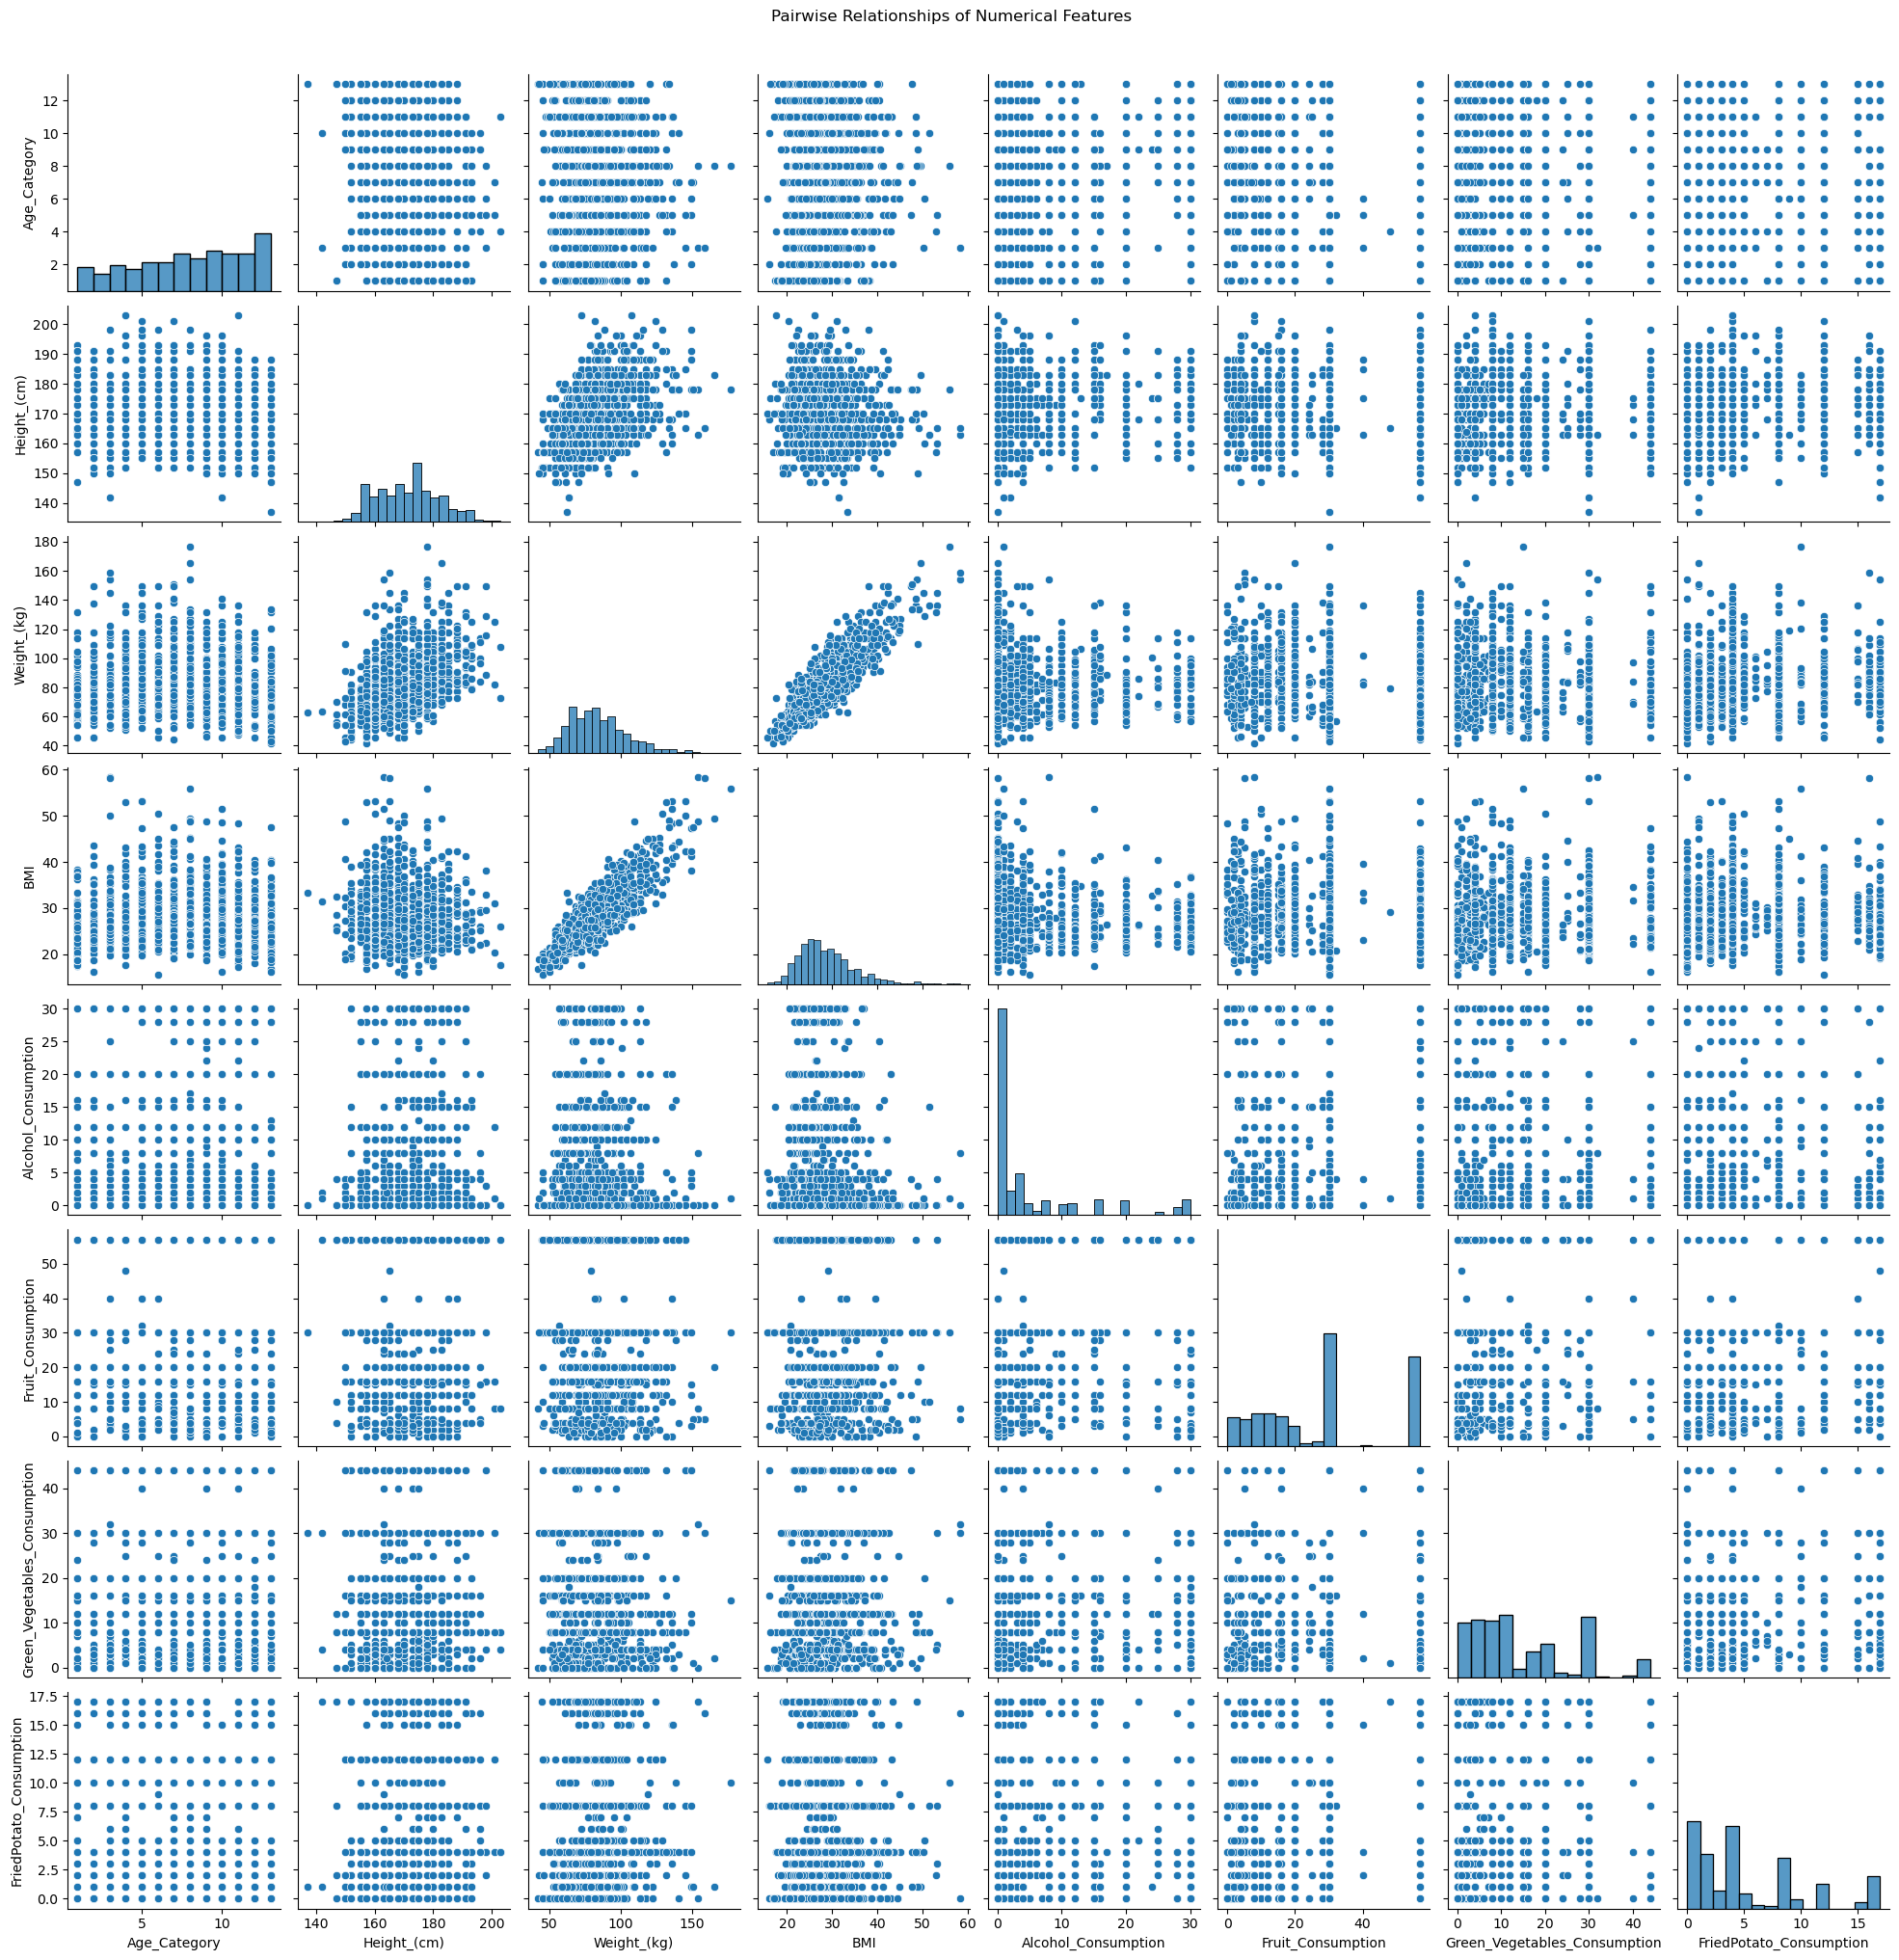

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define numerical columns
numerical_cols = ['Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 
                  'Alcohol_Consumption', 'Fruit_Consumption', 
                  'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

# Sample the data for performance
sns.pairplot(df.sample(1000, random_state=42)[numerical_cols])
plt.suptitle("Pairwise Relationships of Numerical Features", y=1.02)
plt.show()


###  Relationship Between Smoking and Disease
This bar plot illustrates how smoking history influences the prevalence of six lifestyle-related diseases:

Heart Disease

Skin Cancer

Other Cancer

Depression

Diabetes

Arthritis

🔍 Findings:
Smokers exhibit a notably higher prevalence of Heart Disease, Other Cancer, and Depression compared to non-smokers.

Skin Cancer also appears slightly more common among smokers.

Diabetes and Arthritis show a more modest increase, but the trend still exists.

Overall, this reinforces smoking history as a strong lifestyle risk factor that must be accounted for in the predictive model.

This kind of analysis supports the inclusion of Smoking_History as a vital feature in your model to predict disease risks accurately.



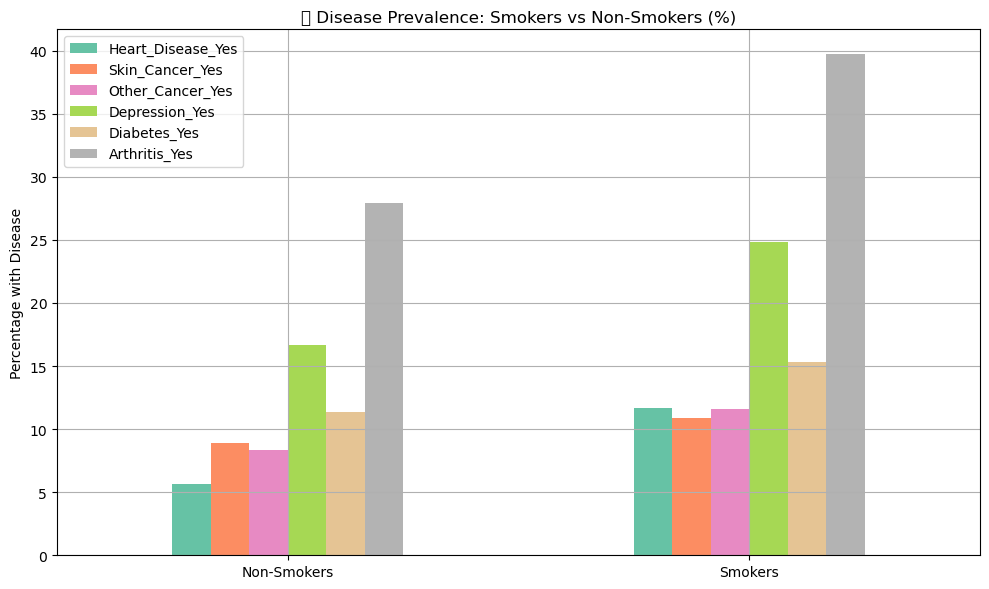

In [32]:
# Define the disease columns again
disease_cols = [
    'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
    'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'
]

# Now compute smoking-disease relationship
smoking_disease = df_encoded.groupby('Smoking_History_Yes')[disease_cols].mean() * 100

# Rename index for clarity
smoking_disease.index = ['Non-Smokers', 'Smokers']

# Plot
smoking_disease.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title("🚬 Disease Prevalence: Smokers vs Non-Smokers (%)")
plt.ylabel("Percentage with Disease")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()


###  Relationship Between Age and Diseases

This bar chart shows how the prevalence of various diseases changes across different age categories. Each disease is averaged within age groups and expressed as a percentage.

#### Key Observations:
- **Heart Disease** and **Arthritis** increase significantly with age, especially after 60 years.
- **Depression** seems more evenly spread across age groups but may decline slightly in older ages.
- **Diabetes** and **Cancer types** (Skin, Other) tend to rise steadily as people age.
- This insight helps reinforce age as a key risk factor in lifestyle-related diseases.

These patterns will help improve the model's predictive accuracy by showing that age is a strong predictor of multiple health outcomes.


<Figure size 1400x700 with 0 Axes>

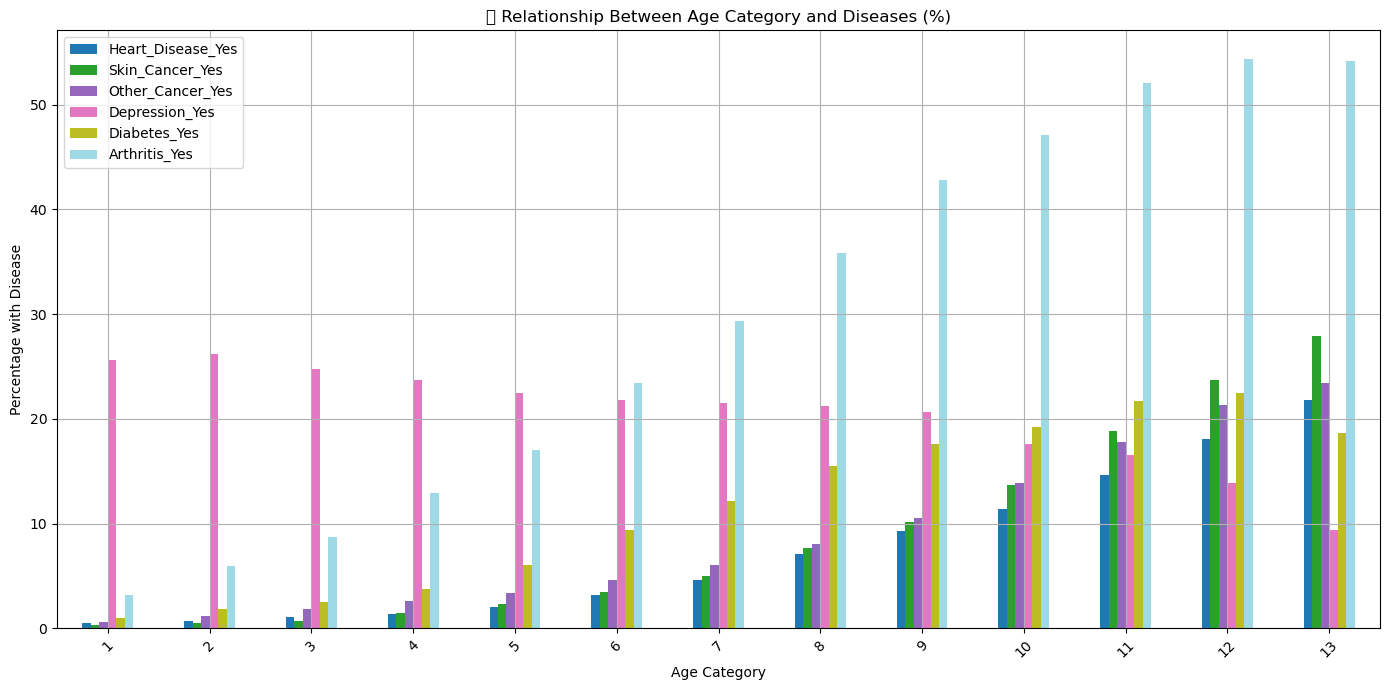

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define disease columns and the age column
disease_cols = [
    'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
    'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'
]

# Group by Age Category and calculate the mean of disease indicators (percentage)
age_disease = df_encoded.groupby('Age_Category')[disease_cols].mean() * 100

# Plot the results
plt.figure(figsize=(14, 7))
age_disease.plot(kind='bar', figsize=(14, 7), colormap='tab20')
plt.title("📊 Relationship Between Age Category and Diseases (%)")
plt.ylabel("Percentage with Disease")
plt.xlabel("Age Category")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


 ### Correlation Between Diseases
This heatmap shows how the presence of one disease correlates with others across the dataset. Each cell reflects a correlation coefficient between two diseases, ranging from -1 (perfect negative) to 1 (perfect positive).

 Key Findings:
Heart Disease, Diabetes, and Arthritis show moderate positive correlations, indicating that individuals with one of these diseases are more likely to have the others.

Depression is moderately linked with Arthritis and Diabetes, suggesting a psychological-lifestyle connection.

Skin Cancer and Other Cancer show some interrelation, which could stem from shared genetic or lifestyle risk factors.

Understanding these patterns can help the model account for comorbidities and improve multi-label prediction accuracy.



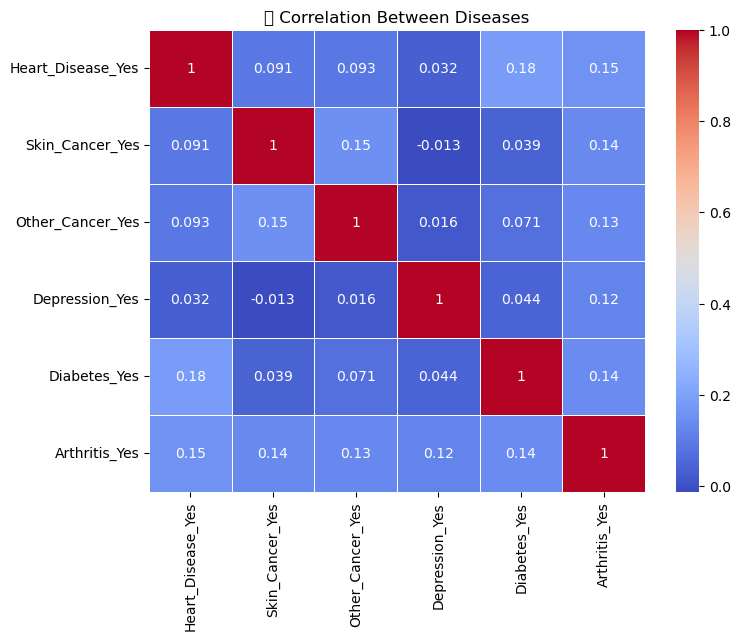

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the disease indicator columns
disease_columns = [
    'Heart_Disease_Yes', 
    'Skin_Cancer_Yes', 
    'Other_Cancer_Yes', 
    'Depression_Yes', 
    'Diabetes_Yes', 
    'Arthritis_Yes'
]

# Compute the correlation matrix
disease_corr = df_encoded[disease_columns].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(disease_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('🔗 Correlation Between Diseases')
plt.show()


### General Health vs Lifestyle Diseases

This graph shows how various lifestyle diseases are distributed across different self-reported general health categories ("Poor", "Fair", "Good", "Very Good").

- **Observation**:
  - Individuals who reported **"Poor" health** tend to have a higher prevalence of diseases such as heart disease, depression, arthritis, and diabetes.
  - The prevalence of diseases decreases as self-rated health improves from **"Fair"** to **"Very Good"**.
  
- **Insight**:
  - There is a clear correlation between general health perception and actual disease presence, indicating that people can reasonably self-assess their wellness in relation to chronic conditions.


<Figure size 1200x600 with 0 Axes>

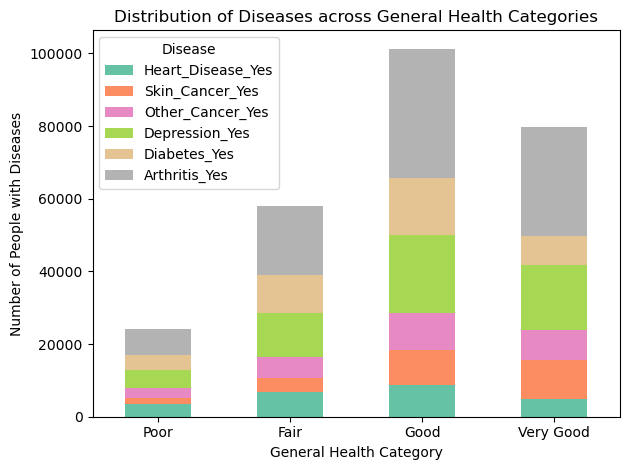

In [38]:
#Step 2: General Health vs Lifestyle Diseases
import matplotlib.pyplot as plt
import seaborn as sns

# Combine general health with disease indicators
health_disease_df = df[[
    'General_Health_Poor', 'General_Health_Fair', 'General_Health_Good', 'General_Health_Very Good',
    'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
    'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'
]]

# Sum up disease indicators for each general health category
health_disease_grouped = {
    'Poor': health_disease_df[df['General_Health_Poor'] == 1].iloc[:, 4:].sum(),
    'Fair': health_disease_df[df['General_Health_Fair'] == 1].iloc[:, 4:].sum(),
    'Good': health_disease_df[df['General_Health_Good'] == 1].iloc[:, 4:].sum(),
    'Very Good': health_disease_df[df['General_Health_Very Good'] == 1].iloc[:, 4:].sum()
}

# Convert to DataFrame for plotting
health_disease_plot_df = pd.DataFrame(health_disease_grouped)

# Plot
plt.figure(figsize=(12, 6))
health_disease_plot_df.T.plot(kind='bar', stacked=True, colormap='Set2')
plt.title("Distribution of Diseases across General Health Categories")
plt.xlabel("General Health Category")
plt.ylabel("Number of People with Diseases")
plt.xticks(rotation=0)
plt.legend(title="Disease")
plt.tight_layout()
plt.show()


### Exercise vs Lifestyle Diseases

This graph visualizes the number of people with each disease, grouped by whether they engage in regular physical exercise.

- **Observation**:
  - People who **do not exercise** show significantly higher cases of heart disease, arthritis, and depression.
  - For most diseases, regular exercise appears to **lower the risk or prevalence**.

- **Insight**:
  - Regular exercise is a protective factor against lifestyle diseases.
  - This supports the importance of physical activity in public health recommendations and lifestyle management programs.


<Figure size 1200x600 with 0 Axes>

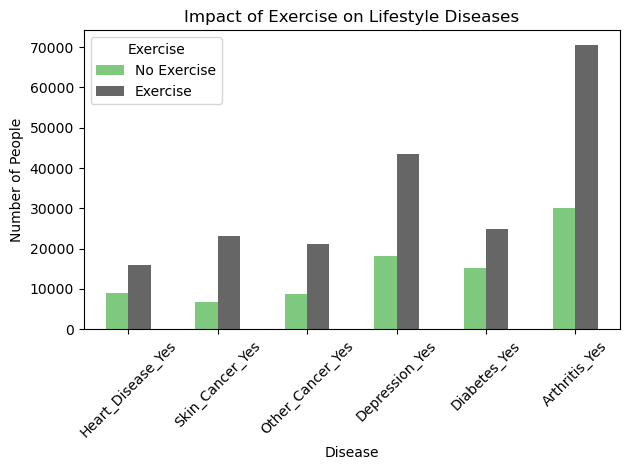

In [40]:
 #Step 3: Exercise vs Lifestyle Diseases
# Create a new DataFrame focused on Exercise and disease presence
exercise_disease_df = df[[
    'Exercise_Yes',
    'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
    'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'
]]

# Group by Exercise and sum disease counts
exercise_grouped = exercise_disease_df.groupby('Exercise_Yes').sum().T

# Rename index for clarity
exercise_grouped.columns = ['No Exercise', 'Exercise']

# Plot
plt.figure(figsize=(12, 6))
exercise_grouped.plot(kind='bar', colormap='Accent')
plt.title("Impact of Exercise on Lifestyle Diseases")
plt.xlabel("Disease")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.legend(title="Exercise")
plt.tight_layout()
plt.show()


### 🧑‍🤝‍🧑 Gender and Disease Prevalence
This bar chart shows how disease prevalence varies between males and females for six lifestyle-related conditions.

🔍 Key Observations:
Heart Disease and Diabetes show slightly higher rates in males.

Depression and Arthritis appear to be more prevalent in females, which aligns with many public health findings.

Cancer rates (Skin and Other Cancer) show small differences between genders, possibly due to screening or risk exposure.

Understanding gender-based differences helps improve fairness and accuracy in predictive healthcare models.

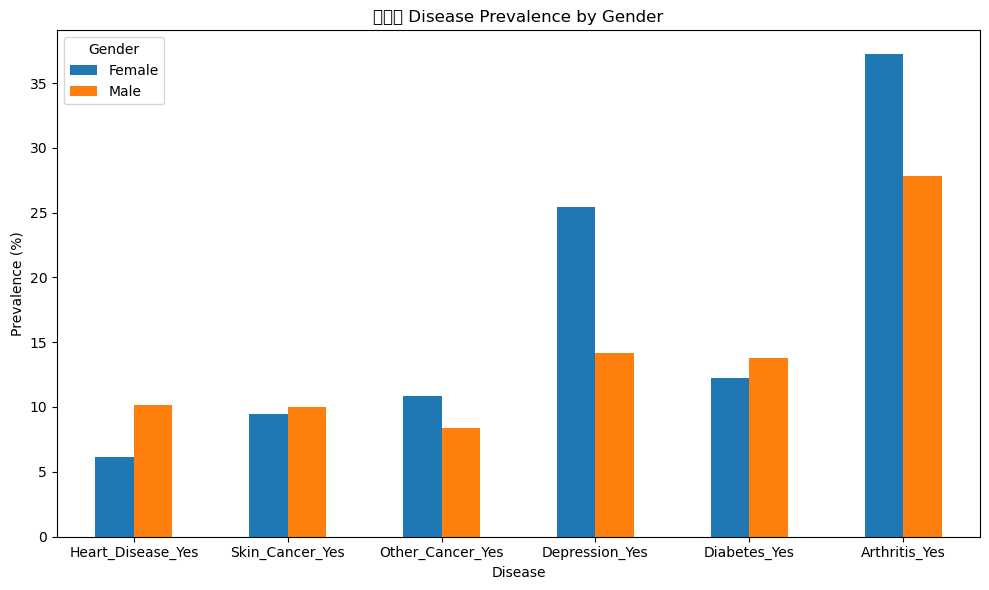

In [42]:
import matplotlib.pyplot as plt

# List of disease columns
disease_cols = [
    'Heart_Disease_Yes', 
    'Skin_Cancer_Yes', 
    'Other_Cancer_Yes', 
    'Depression_Yes', 
    'Diabetes_Yes', 
    'Arthritis_Yes'
]

# Group by gender and compute mean percentages
gender_disease = df_encoded.groupby('Sex_Male')[disease_cols].mean() * 100
gender_disease.index = ['Female', 'Male']  # Rename for readability

# Plotting
gender_disease.T.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('🧑‍🤝‍🧑 Disease Prevalence by Gender')
plt.ylabel('Prevalence (%)')
plt.xlabel('Disease')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


 ### 🍎 Fruit & Vegetable Consumption vs. General Health
This plot helps us understand how healthy eating habits (fruit and green vegetable intake) correlate with self-reported general health status.
    
🥗 Relationship Between Diet and Self-Reported General Health
This boxplot explores how fruit and vegetable consumption varies across different levels of general health.

🔍 Key Observations:
People reporting "Excellent" or "Very Good" health tend to consume more fruits and vegetables.

Those in "Fair" or "Poor" health show lower dietary intake of these healthy food types.

This supports the idea that healthy eating patterns are linked to better health outcomes.



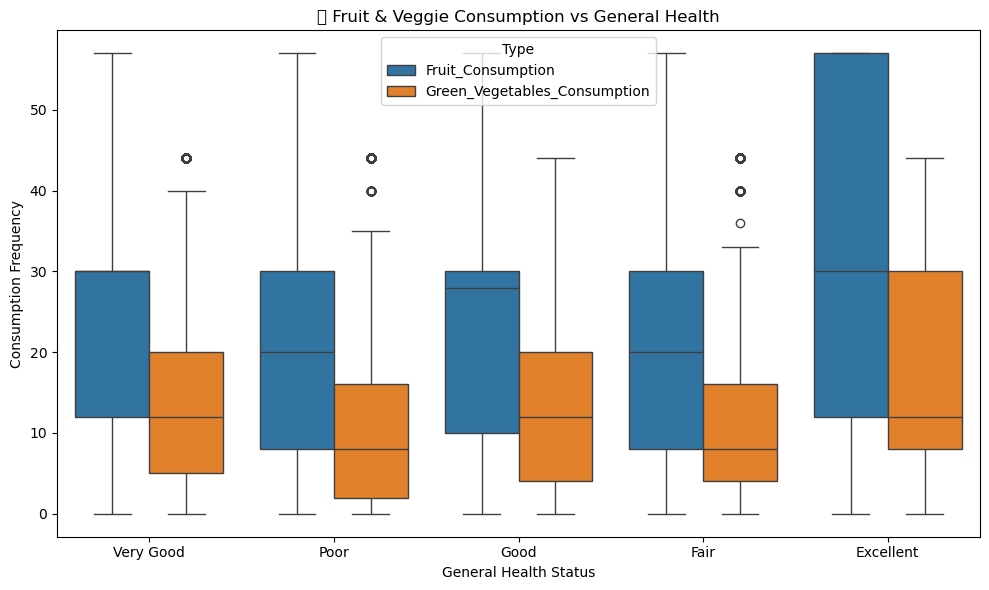

In [44]:
# Define conditions and choices
conditions = [
    df_encoded['General_Health_Excellent'] == 1,
    df_encoded['General_Health_Very Good'] == 1,
    df_encoded['General_Health_Good'] == 1,
    df_encoded['General_Health_Fair'] == 1,
    df_encoded['General_Health_Poor'] == 1,
]

choices = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']

# Create the new 'Health' column
df_encoded['Health'] = np.select(conditions, choices, default=np.nan)

# Filter relevant columns
melted_df = df_encoded[['Fruit_Consumption', 'Green_Vegetables_Consumption', 'Health']].dropna()

# Melt for plotting
melt_long = pd.melt(melted_df, id_vars='Health',
                    value_vars=['Fruit_Consumption', 'Green_Vegetables_Consumption'],
                    var_name='Food Type', value_name='Consumption')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Health', y='Consumption', hue='Food Type', data=melt_long)
plt.title('🍎 Fruit & Veggie Consumption vs General Health')
plt.ylabel('Consumption Frequency')
plt.xlabel('General Health Status')
plt.legend(title='Type')
plt.tight_layout()
plt.show()


 ###  Physical Activity and Disease Count
We'll count how many diseases each individual has and compare it with their exercise habits.

 Relationship Between Physical Activity and Disease Burden
This plot compares the number of lifestyle-related diseases between individuals who exercise regularly and those who don't.

 Key Observations:
Individuals who do not exercise show higher median disease counts.

Exercising regularly seems to reduce the risk of accumulating multiple diseases.

This emphasizes the protective role of physical activity in lifestyle disease prevention.



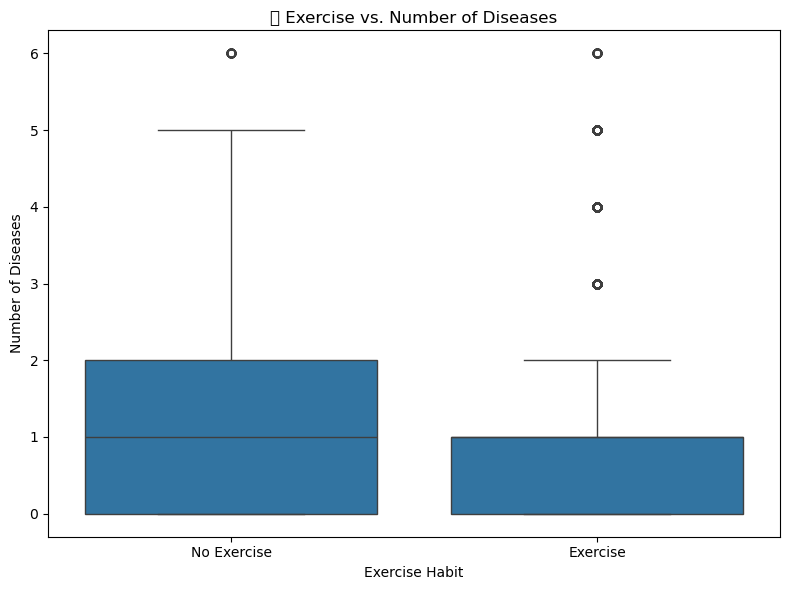

In [46]:
# Add a column for number of diseases
df_encoded['Disease_Count'] = df_encoded[
    ['Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes', 
     'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes']
].sum(axis=1)

# Plot relationship between Exercise and Disease Count
plt.figure(figsize=(8,6))
sns.boxplot(x='Exercise_Yes', y='Disease_Count', data=df_encoded)
plt.xticks([0,1], ['No Exercise', 'Exercise'])
plt.title('🏃 Exercise vs. Number of Diseases')
plt.xlabel('Exercise Habit')
plt.ylabel('Number of Diseases')
plt.tight_layout()
plt.show()


### Step 6: Splitting Features and Targets

In this step, we separate the dataset into:
- `X`: Feature matrix containing all input variables used for prediction (e.g., lifestyle, age, health metrics).
- `y`: Target matrix containing the six lifestyle-related diseases:
  - Heart Disease
  - Skin Cancer
  - Other Cancer
  - Depression
  - Diabetes
  - Arthritis

We also check for:
- Shapes of both `X` and `y`
- Missing values (must be 0 before training the models)

This prepares the data for model training in the next step.


In [48]:
# Define target columns (these are the conditions we're predicting)
target_columns = [
    'Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
    'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'
]

# Split into features (X) and targets (y)
X = df_encoded.drop(columns=target_columns)
y = df_encoded[target_columns]

# Check shapes
print("📐 Feature matrix X shape:", X.shape)
print("🎯 Target matrix y shape:", y.shape)

# Check for missing values
print("\n🧼 Missing values in X:", X.isnull().sum().sum())
print("🧼 Missing values in y:", y.isnull().sum().sum())


📐 Feature matrix X shape: (307963, 34)
🎯 Target matrix y shape: (307963, 6)

🧼 Missing values in X: 0
🧼 Missing values in y: 0


### Step 7: Train-Test Split

To prepare for model training, we split the dataset into training and testing sets using an 80-20 ratio.  
- The **training set** will be used to train the models.
- The **testing set** will be used to evaluate model performance on unseen data.

We used `stratify=y` to preserve the distribution of the target labels during splitting.


In [50]:
from sklearn.model_selection import train_test_split

# Split features and targets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")
print(f"✅ y_test shape: {y_test.shape}")


✅ X_train shape: (246370, 34)
✅ y_train shape: (246370, 6)
✅ X_test shape: (61593, 34)
✅ y_test shape: (61593, 6)


### Step 8: Handling Class Imbalance with SMOTE

Some disease classes may be underrepresented in the dataset, leading to biased predictions.  
To address this, we apply **SMOTE (Synthetic Minority Oversampling Technique)** to balance the data:

- We apply SMOTE individually to each of the 6 disease target labels.
- This generates synthetic samples for the minority class in each target.
- After balancing, the dataset will be more evenly distributed, improving model fairness and accuracy.

We also perform checks to confirm that the new balanced dataset has no missing values.


In [52]:
# Check if any object (string) columns are still present
X_train.select_dtypes(include='object').columns
for col in y_train.columns:
    print(f"{col}: {y_train[col].unique()}")


Heart_Disease_Yes: [False  True]
Skin_Cancer_Yes: [False  True]
Other_Cancer_Yes: [False  True]
Depression_Yes: [ True False]
Diabetes_Yes: [False  True]
Arthritis_Yes: [False  True]


In [53]:
# Convert boolean to integers (True → 1, False → 0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [54]:
# Show non-numeric (object or string) columns
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
print("❗ Non-numeric columns in X_train:", non_numeric_cols.tolist())


❗ Non-numeric columns in X_train: ['Health']


In [55]:
print(X_train.select_dtypes(include='object').columns)


Index(['Health'], dtype='object')


In [56]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 👉 Replace with your actual DataFrame
# df = pd.read_csv('your_dataset.csv')

# ✅ STEP 1: Define your feature columns (already encoded)
feature_columns = [
    'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption',
    'General_Health_Fair', 'General_Health_Good', 'General_Health_Poor', 'General_Health_Very Good',

]

# ✅ STEP 2: Define your target (label) columns
target_columns = ["Heart_Disease_Yes", "Skin_Cancer_Yes","Other_Cancer_Yes","Depression_Yes","Diabetes_Yes", "Arthritis_Yes",]  # <- Replace with actual 6 disease names

# ✅ STEP 3: Split features and targets
X = df[feature_columns]
y = df[target_columns]

# ✅ STEP 4: Train-test split (optional)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ STEP 5: Apply SMOTE to each target column individually
X_train_balanced = []
y_train_balanced = []

for col in y_train.columns:
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train[col])
    
    # Append results
    X_train_balanced.append(pd.DataFrame(X_res, columns=X_train.columns))
    y_train_balanced.append(pd.Series(y_res, name=col))

# ✅ STEP 6: Concatenate balanced data
X_train_balanced = pd.concat(X_train_balanced, axis=0).reset_index(drop=True)
y_train_balanced = pd.concat(y_train_balanced, axis=0).reset_index(drop=True)

# ✅ STEP 7: Regroup y_train_balanced into proper shape
n = len(y_train)
y_train_balanced = pd.DataFrame({
    col: y_train_balanced[i*n:(i+1)*n].reset_index(drop=True)
    for i, col in enumerate(y_train.columns)
})

# ✅ STEP 8: Match lengths
X_train_balanced = X_train_balanced.iloc[:len(y_train_balanced)].reset_index(drop=True)

# ✅ Final Checks
print("✅ Balanced X_train shape:", X_train_balanced.shape)
print("✅ Balanced y_train shape:", y_train_balanced.shape)
print("🧼 Missing values in X:", X_train_balanced.isna().sum().sum())
print("🧼 Missing values in y:", y_train_balanced.isna().sum().sum())


✅ Balanced X_train shape: (246370, 13)
✅ Balanced y_train shape: (246370, 6)
🧼 Missing values in X: 0
🧼 Missing values in y: 0


In [57]:
from imblearn.over_sampling import SMOTE
import pandas as pd
from imblearn.over_sampling import SMOTEN, BorderlineSMOTE

# Borderline-SMOTE works better when classes are noisy
smote = BorderlineSMOTE(random_state=42)

# Initialize empty lists
X_train_balanced = []
y_train_balanced = []

# Apply SMOTE to each of the 6 target labels separately
for col in y_train.columns:
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train[col])
    
    X_train_balanced.append(pd.DataFrame(X_res, columns=X_train.columns))
    y_train_balanced.append(pd.Series(y_res, name=col))

# Concatenate results
X_train_balanced = pd.concat(X_train_balanced, axis=0).reset_index(drop=True)
y_train_balanced = pd.concat(y_train_balanced, axis=0).reset_index(drop=True)

# Group y_train_balanced into proper shape (each target back to its column)
n = len(y_train)
y_train_balanced = pd.DataFrame({
    col: y_train_balanced[i*n:(i+1)*n].reset_index(drop=True)
    for i, col in enumerate(y_train.columns)
})

# Match rows
X_train_balanced = X_train_balanced.iloc[:len(y_train_balanced)].reset_index(drop=True)

# Final checks
print("✅ Balanced X_train shape:", X_train_balanced.shape)
print("✅ Balanced y_train shape:", y_train_balanced.shape)
print("🧼 NaNs in X_train_balanced:", pd.DataFrame(X_train_balanced).isna().sum().sum())
print("🧼 NaNs in y_train_balanced:", y_train_balanced.isna().sum().sum())


✅ Balanced X_train shape: (246370, 13)
✅ Balanced y_train shape: (246370, 6)
🧼 NaNs in X_train_balanced: 0
🧼 NaNs in y_train_balanced: 0


### Step 11: Feature Scaling

To ensure consistent feature magnitude, we use `StandardScaler` to scale the feature data:
- It subtracts the **mean** and divides by the **standard deviation**.
- This gives each feature a mean of 0 and a standard deviation of 1.

This step is crucial for algorithms sensitive to feature scales (e.g., Logistic Regression, SVM).

We scaled:
- `X_train_balanced` → `X_train_scaled`
- `X_test` → `X_test_scaled`

Targets (`y_train_balanced`, `y_test`) are left unchanged since they are binary.


In [59]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Optionally convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Confirm
print("✅ Scaled X_train shape:", X_train_scaled.shape)
print("✅ Scaled X_test shape:", X_test_scaled.shape)


✅ Scaled X_train shape: (246370, 13)
✅ Scaled X_test shape: (61593, 13)


In [60]:
!pip install xgboost scikit-learn


### Step 12A: Train Random Forest using MultiOutputClassifier

We train a `RandomForestClassifier` to predict multiple diseases using `MultiOutputClassifier`.

- `MultiOutputClassifier` allows fitting a separate model for each disease label.
- This enables the model to learn distinct patterns for each disease independently.
- Random Forest is robust to overfitting and performs well on high-dimensional data.

✅ Random Forest has been trained successfully.


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Initialize and wrap Random Forest
rf = RandomForestClassifier(random_state=42)
rf_multi = MultiOutputClassifier(rf)

# Train
print("🧠 Training Random Forest...")
rf_multi.fit(X_train_scaled, y_train_balanced)
print("✅ Random Forest trained.")


🧠 Training Random Forest...
✅ Random Forest trained.


### Step 12B: Train XGBoost using MultiOutputClassifier

We train an `XGBClassifier` for multiple disease targets using `MultiOutputClassifier`.

- XGBoost is known for its performance on structured/tabular data.
- It efficiently handles class imbalance and offers built-in regularization.

✅ XGBoost has been trained successfully.


In [64]:
from xgboost import XGBClassifier

# Initialize and wrap XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_multi = MultiOutputClassifier(xgb)

# Train
print("🧠 Training XGBoost...")
xgb_multi.fit(X_train_scaled, y_train_balanced)
print("✅ XGBoost trained.")


🧠 Training XGBoost...
✅ XGBoost trained.


### Step 12C: Train Logistic Regression using MultiOutputClassifier

We train a `LogisticRegression` model to handle multiple diseases using `MultiOutputClassifier`.

- Logistic Regression is a simple and interpretable baseline model.
- Useful for understanding linear relationships and benchmarking performance.

✅ Logistic Regression has been trained successfully.


In [66]:
from sklearn.linear_model import LogisticRegression

# Initialize and wrap Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg_multi = MultiOutputClassifier(logreg)

# Train
print("🧠 Training Logistic Regression...")
logreg_multi.fit(X_train_scaled, y_train_balanced)
print("✅ Logistic Regression trained.")


🧠 Training Logistic Regression...
✅ Logistic Regression trained.


## Step 13: Model Evaluation

We evaluate the performance of each model using:

- **Classification Report** (Precision, Recall, F1-Score per target)
- **Overall Accuracy** (average across all labels)

The report helps us understand how well each model is predicting each disease.
This insight is critical before deploying the model or proceeding to Streamlit/Power BI.

✅ Models evaluated on test set.


In [68]:
from sklearn.metrics import classification_report, accuracy_score

# Function to evaluate a multi-output model
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"\n📊 Evaluation Report for {model_name}")
    
    y_pred = model.predict(X_test)
    for i, col in enumerate(y_test.columns):
        print(f"\n🔹 Target: {col}")
        print(classification_report(y_test.iloc[:, i], y_pred[:, i]))
    
    # Calculate overall accuracy (average over labels)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Overall Accuracy: {acc:.4f}")


In [69]:
evaluate_model(rf_multi, X_test_scaled, y_test, model_name="Random Forest")



📊 Evaluation Report for Random Forest

🔹 Target: Heart_Disease_Yes
              precision    recall  f1-score   support

       False       0.92      0.99      0.96     56590
        True       0.36      0.05      0.09      5003

    accuracy                           0.92     61593
   macro avg       0.64      0.52      0.52     61593
weighted avg       0.88      0.92      0.89     61593


🔹 Target: Skin_Cancer_Yes
              precision    recall  f1-score   support

       False       0.91      0.00      0.00     55658
        True       0.10      1.00      0.18      5935

    accuracy                           0.10     61593
   macro avg       0.50      0.50      0.09     61593
weighted avg       0.83      0.10      0.02     61593


🔹 Target: Other_Cancer_Yes
              precision    recall  f1-score   support

       False       0.90      0.99      0.94     55654
        True       0.11      0.01      0.02      5939

    accuracy                           0.90     61593
   ma

In [70]:
evaluate_model(xgb_multi, X_test_scaled, y_test, model_name="XGBoost")



📊 Evaluation Report for XGBoost

🔹 Target: Heart_Disease_Yes
              precision    recall  f1-score   support

       False       0.92      1.00      0.96     56590
        True       0.47      0.04      0.08      5003

    accuracy                           0.92     61593
   macro avg       0.69      0.52      0.52     61593
weighted avg       0.88      0.92      0.89     61593


🔹 Target: Skin_Cancer_Yes
              precision    recall  f1-score   support

       False       0.92      0.00      0.00     55658
        True       0.10      1.00      0.18      5935

    accuracy                           0.10     61593
   macro avg       0.51      0.50      0.09     61593
weighted avg       0.84      0.10      0.02     61593


🔹 Target: Other_Cancer_Yes
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     55654
        True       0.06      0.00      0.00      5939

    accuracy                           0.90     61593
   macro av

In [71]:
evaluate_model(logreg_multi, X_test_scaled, y_test, model_name="Logistic Regression")



📊 Evaluation Report for Logistic Regression

🔹 Target: Heart_Disease_Yes
              precision    recall  f1-score   support

       False       0.92      0.99      0.96     56590
        True       0.47      0.05      0.10      5003

    accuracy                           0.92     61593
   macro avg       0.70      0.52      0.53     61593
weighted avg       0.89      0.92      0.89     61593


🔹 Target: Skin_Cancer_Yes
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     55658
        True       0.10      1.00      0.18      5935

    accuracy                           0.10     61593
   macro avg       0.05      0.50      0.09     61593
weighted avg       0.01      0.10      0.02     61593


🔹 Target: Other_Cancer_Yes
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     55654
        True       0.00      0.00      0.00      5939

    accuracy                           0.90     61593

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

# Initialize models
rf_model = MultiOutputClassifier(RandomForestClassifier(random_state=42))
xgb_model = MultiOutputClassifier(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Train all models using SMOTE-balanced data
print("Training Random Forest...")
rf_model.fit(X_train_balanced, y_train_balanced)

print("Training XGBoost...")
xgb_model.fit(X_train_balanced, y_train_balanced)

print("Training Logistic Regression...")
lr_model.fit(X_train_balanced, y_train_balanced)


Training Random Forest...
Training XGBoost...
Training Logistic Regression...


MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000,
                                                   random_state=42))

## 📦 Step 1: Saving the Trained XGBoost Model and Scaler

After training our XGBoost model using the MultiOutputClassifier, we now save the trained model to disk using `joblib`. This allows us to reuse the model later without retraining it.

We also save the `scaler` used for transforming the input features. This ensures that during prediction, the new user input is transformed in the same way as the training data.

- `xgboost_model.pkl`: Contains the trained multi-output XGBoost model.
- `scaler.pkl`: Contains the fitted scaler object used to scale inputs.


In [74]:
import joblib

# Save the trained XGBoost multi-output classifier
joblib.dump(xgb_multi, 'xgboost_model.pkl')

# Save the scaler so we can use it during prediction
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [75]:
joblib.dump(xgb_multi, 'xgboost_model.pkl')


['xgboost_model.pkl']

In [76]:
['xgboost_model.pkl']


['xgboost_model.pkl']

### 🧠 Disease Prediction Function

This section defines a function called `predict_diseases` which uses the trained XGBoost model to predict six different lifestyle-related diseases based on a user's input data.

#### ✅ Steps Performed:

1. **Load the Trained Model and Scaler**
   - Loads the saved XGBoost model (`xgboost_model.pkl`) and the corresponding StandardScaler (`scaler.pkl`) that were used during training.

2. **Input Conversion**
   - Accepts input as either a dictionary or a DataFrame.
   - Converts dictionary input into a DataFrame with a single row.

3. **Scaling**
   - Uses the previously saved scaler to normalize the input features before prediction. This ensures consistency with the training phase.

4. **Prediction**
   - Applies the model to the scaled input data to predict the likelihood of each disease.
   - The model outputs binary values (1 = disease present, 0 = disease not present).

5. **Output Formatting**
   - Maps the model's output to disease labels:
     - `'Heart_Disease_Yes'`
     - `'Skin_Cancer_Yes'`
     - `'Other_Cancer_Yes'`
     - `'Depression_Yes'`
     - `'Diabetes_Yes'`
     - `'Arthritis_Yes'`
   - Returns a dictionary of disease predictions that is ready to use in a Streamlit app or Power BI dashboard.

> This function acts as the prediction engine for our application and will be used for real-time results when a user inputs their health and lifestyle details.


In [78]:
import joblib
import pandas as pd

# Load the saved model and scaler
model = joblib.load('xgboost_model.pkl')
scaler = joblib.load('scaler.pkl')

# Define prediction function
def predict_diseases(input_data):
    """
    input_data: dict or DataFrame with 33 input features (same order used during training)
    """
    # Convert to DataFrame if dict
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data

    # Scale the input
    input_scaled = scaler.transform(input_df)

    # Predict
    predictions = model.predict(input_scaled)

    # Output results as dictionary with disease labels
    target_labels = ['Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes',
                     'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes']
    
    prediction_dict = dict(zip(target_labels, predictions[0]))
    
    return prediction_dict


Model Loading and Prediction Function
In this step, we are preparing our trained XGBoost model for deployment by loading it from disk and creating a prediction function.

Loading the Model and Scaler

We previously saved our trained XGBoost model as xgboost_model.pkl.

We also saved the scaler.pkl, which is used to scale input features the same way we scaled the training data.

Using joblib.load(), we load both the model and the scaler into memory.

Defining predict_diseases Function

This function takes new user input (a dictionary or DataFrame of 33 features) and:

Converts the input into a DataFrame (if it’s a dictionary).

Scales the input using the loaded scaler.

Uses the loaded model to make predictions.

Maps the prediction results to the target labels:
['Heart_Disease_Yes', 'Skin_Cancer_Yes', 'Other_Cancer_Yes', 'Depression_Yes', 'Diabetes_Yes', 'Arthritis_Yes'].

Why We Need to Run It First

The predict_diseases function must be defined in your notebook before you can call it.

If you run a different cell before defining it, Python won’t know what predict_diseases is, which causes the NameError.

Testing the Prediction

We create a sample_input dictionary with example feature values.

When we call predict_diseases(sample_input), the function returns a dictionary showing predicted values (0 or 1) for each disease.



In [80]:
# ==== 1) Imports & loading artifacts ====
import joblib
import pandas as pd
import numpy as np

# Load model & scaler
model = joblib.load('xgboost_model.pkl')   # MultiOutputClassifier(XGBClassifier)
scaler = joblib.load('scaler.pkl')         # The scaler you fit on X_train

# Try to recover the exact feature order used during training
try:
    EXPECTED_FEATURES = list(scaler.feature_names_in_)
except AttributeError:
    raise RuntimeError(
        "Your scaler doesn't expose `feature_names_in_`. "
        "Please save and load the list of feature names you trained on "
        "(e.g., with joblib.dump(feature_names, 'feature_names.pkl'))."
    )

TARGET_LABELS = [
    'Heart_Disease_Yes',
    'Skin_Cancer_Yes',
    'Other_Cancer_Yes',
    'Depression_Yes',
    'Diabetes_Yes',
    'Arthritis_Yes'
]

# ==== 2) Prediction helper ====
def predict_diseases(input_data):
    """
    Parameters
    ----------
    input_data : dict or pandas.DataFrame
        Must contain the same feature names the model was trained on.
        Any missing columns will be added with 0s, and columns will be reordered automatically.

    Returns
    -------
    dict
        {target_label: 0/1, ...}
    """

    # Convert to DataFrame
    if isinstance(input_data, dict):
        df_in = pd.DataFrame([input_data])
    else:
        df_in = input_data.copy()

    # Add any missing columns with 0s
    for col in EXPECTED_FEATURES:
        if col not in df_in.columns:
            df_in[col] = 0

    # Drop any unexpected extra columns
    df_in = df_in[EXPECTED_FEATURES]

    # Scale
    X_scaled = scaler.transform(df_in)

    # Predict
    preds = model.predict(X_scaled)

    # If MultiOutputClassifier, preds is (n_samples, n_targets)
    preds = preds[0]  # we passed 1 row

    return dict(zip(TARGET_LABELS, preds))

# ==== 3) Quick test with a synthetic sample ====
# Build a zeroed template first
sample_input = {f: 0 for f in EXPECTED_FEATURES}

# Fill a few sensible numeric values if those columns exist
sample_input.update({
    'Age_Category': 45 if 'Age_Category' in EXPECTED_FEATURES else 0,
    'Height_(cm)': 170 if 'Height_(cm)' in EXPECTED_FEATURES else 0,
    'Weight_(kg)': 75 if 'Weight_(kg)' in EXPECTED_FEATURES else 0,
    'BMI': 26 if 'BMI' in EXPECTED_FEATURES else 0,
    'Alcohol_Consumption': 2 if 'Alcohol_Consumption' in EXPECTED_FEATURES else 0,
    'Fruit_Consumption': 20 if 'Fruit_Consumption' in EXPECTED_FEATURES else 0,
    'Green_Vegetables_Consumption': 10 if 'Green_Vegetables_Consumption' in EXPECTED_FEATURES else 0,
    'FriedPotato_Consumption': 4 if 'FriedPotato_Consumption' in EXPECTED_FEATURES else 0,
})

# Set one-hot flags (only if they exist in your features)
for col in ['Sex_Male', 'Exercise_Yes', 'Smoking_History_Yes']:
    if col in EXPECTED_FEATURES:
        sample_input[col] = 1

# Make sure we are not setting conflicting one-hots.
# (e.g., if Sex_Male = 1, make Sex_Female = 0, etc.)

print("🔎 Running a test prediction...")
result = predict_diseases(sample_input)
print("✅ Prediction:", result)


🔎 Running a test prediction...
✅ Prediction: {'Heart_Disease_Yes': 0, 'Skin_Cancer_Yes': 1, 'Other_Cancer_Yes': 0, 'Depression_Yes': 1, 'Diabetes_Yes': 0, 'Arthritis_Yes': 1}


In [81]:
import joblib

# Save the feature names used in training
joblib.dump(X.columns.tolist(), "Models/training_columns.pkl")

# Save your model (already done)
joblib.dump(model, "Models/xgboost_model.pkl")


['Models/xgboost_model.pkl']

In [148]:
import joblib
joblib.dump(list(X_train_scaled.columns), "feature_columns.pkl")


['feature_columns.pkl']